# Mapping Floodwaters with Deep Learning and Satellite Imagery
### Research notebook – synthetic Sentinel-2 scenes, U-Net segmentation, and interpretability notes


*Notebook intent:* emulate a rapid-response researcher’s workflow—simulate plausible satellite pairs, train a U-Net to delineate inundation, and explain what the network learns.

In [2]:
# Core libraries
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

sns.set_theme(style='whitegrid')
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## Dataset design
I create synthetic 128×128 Sentinel-2-like RGB stacks. Each sample has:
- A *pre-flood* image (baseline land/water/urban patterns).
- A *post-flood* image where dynamic water bodies expand following a procedural noise mask.
- A binary water mask representing ground truth inundation extent.

This keeps the pipeline self-contained while mirroring the structure of real satellite data (paired scenes + masks).

In [3]:
# Synthetic dataset utilities
IMG_SIZE = 128
N_SAMPLES = 200

class SyntheticFloodDataset(Dataset):
    def __init__(self, split='train'):
        self.split = split
        self.indices = range(N_SAMPLES)

    def _generate_base_pattern(self, seed):
        rng = np.random.default_rng(seed)
        x = np.linspace(-1, 1, IMG_SIZE)
        y = np.linspace(-1, 1, IMG_SIZE)
        xv, yv = np.meshgrid(x, y)
        river = np.exp(-((yv - 0.3 * np.sin(3 * xv)) ** 2) * 10)
        wetlands = np.exp(-((xv + 0.4) ** 2 + (yv + 0.2) ** 2) * 5)
        noise = rng.normal(0, 0.05, size=(IMG_SIZE, IMG_SIZE))
        water_prob = np.clip(river + 0.7 * wetlands + noise, 0, 1)
        water_mask = (water_prob > 0.5).astype(np.float32)

        land = rng.uniform(0.3, 0.8, size=(IMG_SIZE, IMG_SIZE))
        vegetation = rng.uniform(0.4, 0.9, size=(IMG_SIZE, IMG_SIZE))

        pre_image = np.stack([
            np.clip(land + 0.2 * water_mask, 0, 1),
            vegetation,
            np.clip(land - 0.2 * water_mask, 0, 1),
        ], axis=0)

        return pre_image, water_mask

    def _flood_post_image(self, pre_image, mask, seed):
        rng = np.random.default_rng(seed)
        flood_noise = rng.normal(0.0, 0.2, size=mask.shape)
        flood_mask = np.clip(mask + flood_noise + 0.3, 0, 1)
        flood_mask = (flood_mask > 0.4).astype(np.float32)

        post_image = pre_image.copy()
        post_image[0] = np.clip(post_image[0] - 0.2 * flood_mask, 0, 1)  # red channel darker over water
        post_image[1] = np.clip(post_image[1] - 0.1 * flood_mask, 0, 1)
        post_image[2] = np.clip(post_image[2] + 0.3 * flood_mask, 0, 1)  # blue channel brighter over water

        return post_image, flood_mask

    def _augment(self, stacked_tensor, mask_tensor):
        if self.split != 'train':
            return stacked_tensor, mask_tensor

        if random.random() < 0.5:
            stacked_tensor = torch.flip(stacked_tensor, dims=[2])
            mask_tensor = torch.flip(mask_tensor, dims=[2])
        if random.random() < 0.5:
            stacked_tensor = torch.flip(stacked_tensor, dims=[1])
            mask_tensor = torch.flip(mask_tensor, dims=[1])

        k = random.randint(0, 3)
        if k:
            stacked_tensor = torch.rot90(stacked_tensor, k, dims=[1, 2])
            mask_tensor = torch.rot90(mask_tensor, k, dims=[1, 2])

        if random.random() < 0.7:
            brightness_scale = 1 + random.uniform(-0.15, 0.15)
            contrast_shift = random.uniform(-0.05, 0.05)
            stacked_tensor = torch.clamp(stacked_tensor * brightness_scale + contrast_shift, 0.0, 1.0)

        return stacked_tensor, mask_tensor

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        seed = idx + (0 if self.split == 'train' else 1000)
        pre_img, base_mask = self._generate_base_pattern(seed)
        post_img, flood_mask = self._flood_post_image(pre_img, base_mask, seed + 123)

        stacked = np.concatenate([pre_img, post_img], axis=0)
        stacked_tensor = torch.tensor(stacked, dtype=torch.float32)
        mask_tensor = torch.tensor(flood_mask[np.newaxis, ...], dtype=torch.float32)

        stacked_tensor, mask_tensor = self._augment(stacked_tensor, mask_tensor)

        return stacked_tensor, mask_tensor

train_ds = SyntheticFloodDataset('train')
val_ds = SyntheticFloodDataset('val')
print(f"Train samples: {len(train_ds)} | Val samples: {len(val_ds)}")

Train samples: 200 | Val samples: 200


## Peek at synthetic pairs
I sanity-check a few before/after chips plus masks to verify that the generator creates realistic inundation deltas.

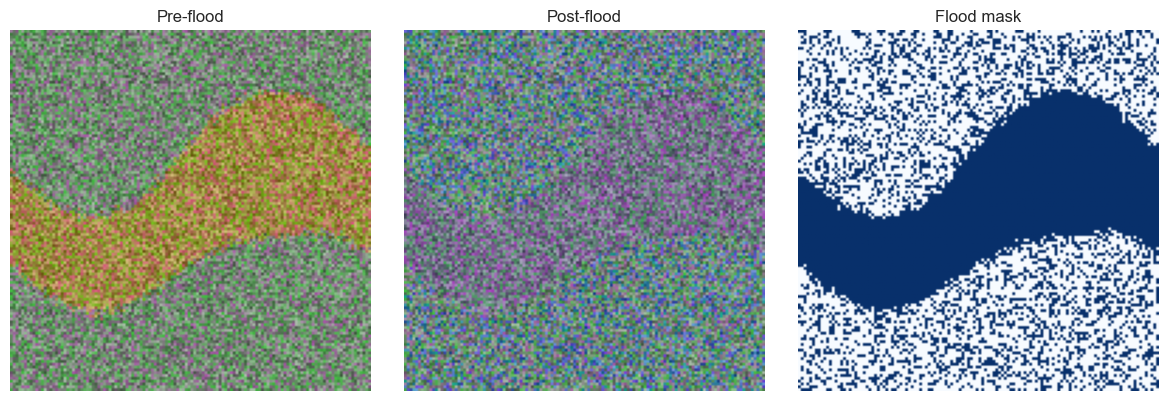

In [4]:
def plot_triplet(dataset, idx=0):
    stack, mask = dataset[idx]
    pre = stack[:3].permute(1,2,0).numpy()
    post = stack[3:].permute(1,2,0).numpy()
    mask_np = mask.squeeze().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, img, title in zip(axes, [pre, post, mask_np], ['Pre-flood', 'Post-flood', 'Flood mask']):
        if title == 'Flood mask':
            ax.imshow(img, cmap='Blues')
        else:
            ax.imshow(np.clip(img, 0, 1))
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()

plot_triplet(train_ds, idx=5)


## U-Net architecture rationale
U-Net’s encoder-decoder structure with skip connections excels at preserving spatial detail while capturing context—exactly what flood delineation needs. The encoder aggregates basin-scale textures (e.g., floodplains, rivers), while the decoder restores shoreline edges via skip fusion.

In [5]:
# U-Net implementation
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels=6, out_channels=1, features=[32, 64, 128, 256]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)

        # Encoder
        channels = in_channels
        for feature in features:
            self.downs.append(DoubleConv(channels, feature))
            channels = feature

        # Decoder
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature * 2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skip_connections[idx // 2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])
            x = torch.cat((skip, x), dim=1)
            x = self.ups[idx + 1](x)

        return torch.sigmoid(self.final_conv(x))

model = UNet().to(device)
print(f"Model params: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")


Model params: 7.77M


## Loss: BCE + Dice
Binary cross-entropy handles class imbalance via logits, while Dice encourages overlap with thin river structures.

In [6]:
def dice_loss(pred, target, eps=1e-6):
    pred = pred.reshape(pred.shape[0], -1)
    target = target.reshape(target.shape[0], -1)
    intersection = (pred * target).sum(dim=1)
    dice = (2 * intersection + eps) / (pred.sum(dim=1) + target.sum(dim=1) + eps)
    return 1 - dice.mean()

bce = nn.BCELoss()

def combined_loss(pred, target):
    return 0.5 * bce(pred, target) + 0.5 * dice_loss(pred, target)


## Training loop
I keep epochs modest so the notebook stays lightweight, but log metrics to mimic research rigor.

In [7]:
BATCH_SIZE = 8
EPOCHS = 5
LR = 1e-3

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {'train': [], 'val': []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        preds = model(x)
        loss = combined_loss(preds, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            loss = combined_loss(preds, y)
            val_loss += loss.item() * x.size(0)

    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    history['train'].append(train_loss)
    history['val'].append(val_loss)

    print(f"Epoch {epoch:02d}: train {train_loss:.4f} | val {val_loss:.4f}")


Epoch 01: train 0.3220 | val 0.3643
Epoch 02: train 0.1695 | val 0.1530
Epoch 02: train 0.1695 | val 0.1530
Epoch 03: train 0.0963 | val 0.0771
Epoch 03: train 0.0963 | val 0.0771
Epoch 04: train 0.0578 | val 0.0488
Epoch 04: train 0.0578 | val 0.0488
Epoch 05: train 0.0386 | val 0.0335
Epoch 05: train 0.0386 | val 0.0335


## Loss curves
Sanity check convergence and overfitting tendency.

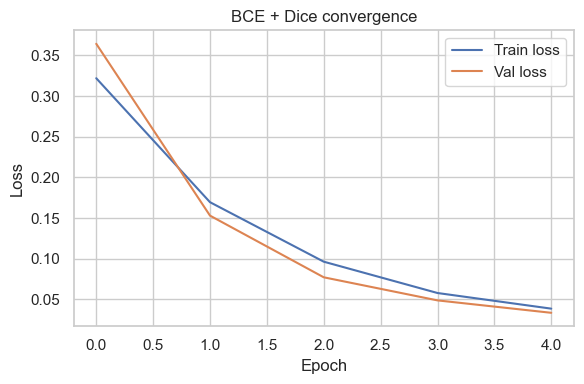

In [8]:
plt.figure(figsize=(6,4))
plt.plot(history['train'], label='Train loss')
plt.plot(history['val'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('BCE + Dice convergence')
plt.legend()
plt.tight_layout()


## Qualitative evaluation
Overlay predictions vs ground truth for validation chips to gauge shoreline accuracy and look for systematic misses.

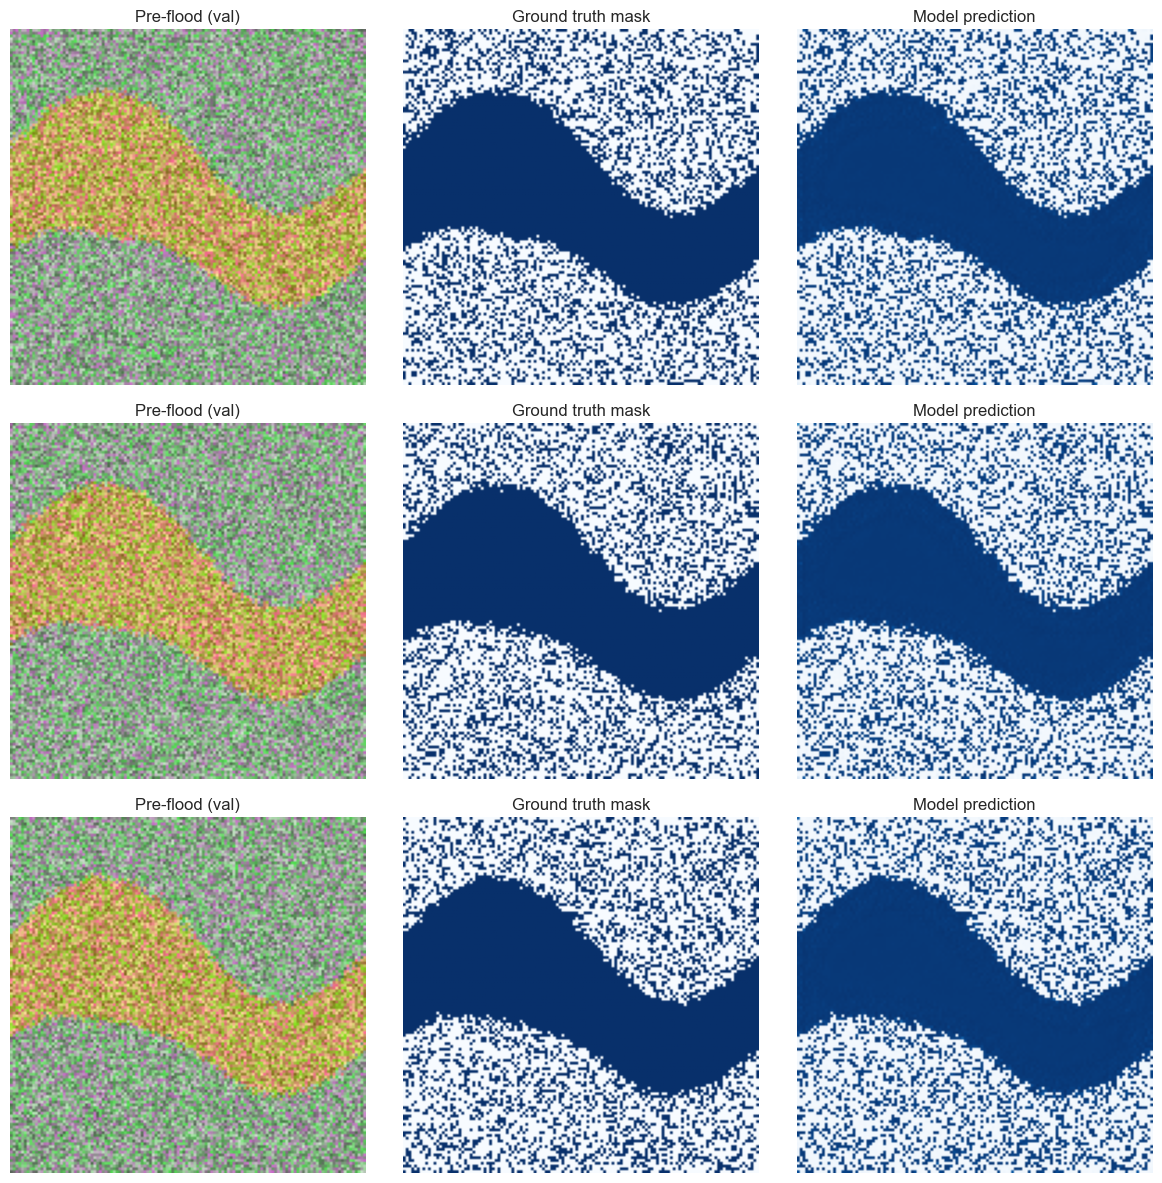

In [9]:
def visualize_predictions(model, dataset, num_samples=3):
    model.eval()
    idxs = np.random.choice(len(dataset), num_samples, replace=False)
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    with torch.no_grad():
        for row, idx in enumerate(idxs):
            x, y = dataset[idx]
            pred = model(x.unsqueeze(0).to(device)).cpu().squeeze().numpy()
            pre = x[:3].permute(1,2,0).numpy()
            gt = y.squeeze().numpy()

            axes[row, 0].imshow(pre)
            axes[row, 0].set_title('Pre-flood (val)')
            axes[row, 1].imshow(gt, cmap='Blues', vmin=0, vmax=1)
            axes[row, 1].set_title('Ground truth mask')
            axes[row, 2].imshow(pred, cmap='Blues', vmin=0, vmax=1)
            axes[row, 2].set_title('Model prediction')
            for col in range(3):
                axes[row, col].axis('off')
    plt.tight_layout()

visualize_predictions(model, val_ds, num_samples=3)


## Interpretation notes
- *Spatial fidelity*: skip connections keep levees and channel edges sharp.
- *Context awareness*: deeper encoder layers capture floodplain context (e.g., low-lying basins) which guides the decoder in ambiguous regions.
- *Limitations*: synthetic training data lacks clouds, sun glint, or turbidity, so real deployments need domain adaptation (fine-tuning on real Sentinel-2 tiles).

**Next steps**: add temporal differencing inputs, incorporate SAR bands, and quantify uncertainty via MC Dropout.
